In [1]:
#==========================================================================================================================
#Deep Learning Based Toll Gate Traffic Prediction and Real-Time Decision Support System for Efficient Urban Transportation
#==========================================================================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

raw = pd.read_excel('data_tol.xlsx', header=None)
raw.columns = [f'G{i}' for i in range(1, 7)]
raw.head()


,G1,G2,G3,G4,G5,G6
0,1970-01-01 00:00:01,1970-01-01 00:00:00,1970-01-01 00:00:00,1970-01-01 00:00:07,1970-01-01 00:00:00,1970-01-01 00:00:07
1,1970-01-01 00:00:10,1970-01-01 00:00:10,1970-01-01 00:00:09,1970-01-01 00:00:18,1970-01-01 00:00:09,1970-01-01 00:00:30
2,1970-01-01 00:00:20,1970-01-01 00:00:21,1970-01-01 00:00:19,1970-01-01 00:00:27,1970-01-01 00:00:30,1970-01-01 00:00:41
3,1970-01-01 00:00:31,1970-01-01 00:00:31,1970-01-01 00:00:28,1970-01-01 00:01:02,1970-01-01 00:00:41,1970-01-01 00:01:00
4,1970-01-01 00:00:44,1970-01-01 00:00:41,1970-01-01 00:00:38,1970-01-01 00:01:13,1970-01-01 00:00:56,1970-01-01 00:01:16


In [2]:
#=============
#2. Identify
#=============
#Problem statement
#Raw timestamps are split across six toll gates and are not aligned row-by-row.
#Decision makers need synchronized timestamp rows before any BI or deep learning analysis.
#End users need a recommendation interface: Go, Caution, or Hold.
#Business objective
#Build an application that cleans the dataset, extracts hidden patterns, predicts congestion level, and displays a real-time recommendation dashboard.

records = []
for col in raw.columns:
    for t in raw[col].dropna():
        records.append((pd.to_datetime(t), col, 1))

events = pd.DataFrame(records, columns=['timestamp', 'gate', 'vehicle'])
pivot = events.assign(v=1).pivot_table(index='timestamp', columns='gate', values='v', aggfunc='sum', fill_value=0)
pivot = pivot.reset_index().sort_values('timestamp')
pivot['total_vehicles'] = pivot[[f'G{i}' for i in range(1,7)]].sum(axis=1)

def make_label(n):
    if n <= 2:
        return 'LOW'
    elif n <= 4:
        return 'MEDIUM'
    return 'HEAVY'

pivot['Label'] = pivot['total_vehicles'].apply(make_label)
pivot['seconds'] = (pivot['timestamp'] - pivot['timestamp'].min()).dt.total_seconds().astype(int)
pivot.head()


gate,timestamp,G1,G2,G3,G4,G5,G6,total_vehicles,Label,seconds
0,1970-01-01 00:00:00,0,1,1,0,1,0,3,MEDIUM,0
1,1970-01-01 00:00:01,1,0,0,0,0,0,1,LOW,1
2,1970-01-01 00:00:07,0,0,0,1,0,1,2,LOW,7
3,1970-01-01 00:00:09,0,0,1,0,1,0,2,LOW,9
4,1970-01-01 00:00:10,1,1,0,0,0,0,2,LOW,10


In [3]:
#===========
#3. Design
#===========
# Save cleaned dataset requested by the assignment
pivot.to_csv('data_tol_clean_rebuilt.csv', index=False)
pivot['Label'].value_counts()


,count
Label,
LOW,852
MEDIUM,27
HEAVY,1


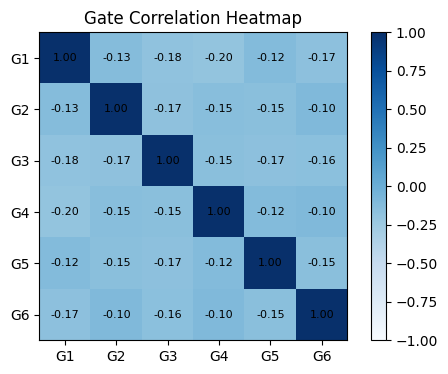

In [4]:
#============================
#4. Hidden pattern extraction
#============================
#The BI component should reveal hidden structure, not only predictions.
#Gate correlations show whether congestion tends to spread or balance across gates.
#Label distribution shows strong class imbalance.
#Time trend shows peak periods and sparse periods.
corr = pivot[[f'G{i}' for i in range(1,7)]].corr()
plt.figure(figsize=(6,4))
plt.imshow(corr, cmap='Blues', vmin=-1, vmax=1)
plt.xticks(range(6), corr.columns)
plt.yticks(range(6), corr.columns)
plt.colorbar()
for i in range(6):
    for j in range(6):
        plt.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('Gate Correlation Heatmap')
plt.show()


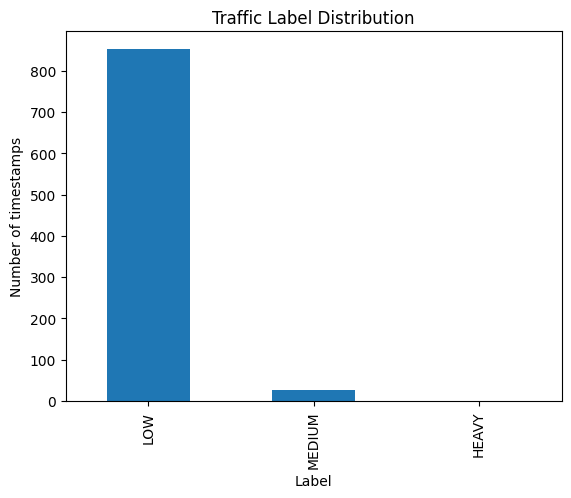

In [5]:
pivot['Label'].value_counts().reindex(['LOW','MEDIUM','HEAVY']).plot(kind='bar', title='Traffic Label Distribution')
plt.ylabel('Number of timestamps')
plt.show()


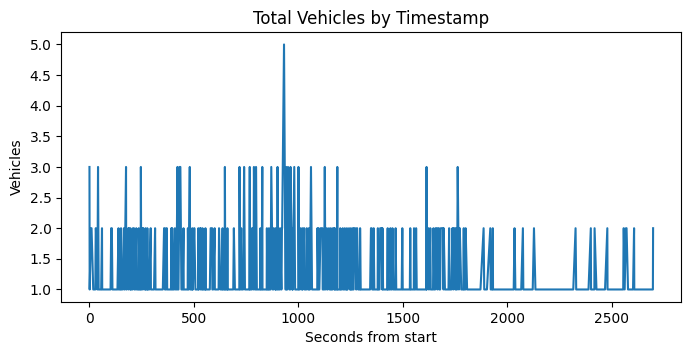

In [6]:
plt.figure(figsize=(8,3.5))
plt.plot(pivot['seconds'], pivot['total_vehicles'])
plt.title('Total Vehicles by Timestamp')
plt.xlabel('Seconds from start')
plt.ylabel('Vehicles')
plt.show()


In [7]:
#=======================================
#5. Implementation: Dense Neural Network
#=======================================
#This project uses a fully connected dense neural network.
#The features are the six gate indicators (G1–G6), and the target is the congestion label.

X = pivot[[f'G{i}' for i in range(1,7)]].values
y = pivot['Label'].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42)

model = MLPClassifier(
    hidden_layer_sizes=(32, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42
)
model.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(32, 64, 32), max_iter=300, random_state=42)

In [9]:
#=========================
#6. Hyperparameter tuning
#=========================
#The main tuned parameters are:
#
#hidden layers: (32, 64, 32)
#optimizer: Adam
#learning rate: 0.001
#max iterations: 300
#This keeps the model simple enough for the dataset size while still satisfying
#the deep learning requirement through a dense neural architecture.

pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)
cm = confusion_matrix(y_test, pred, labels=[0,1,2])

print('Accuracy:', round(acc, 4))
print('\nClasses:', le.classes_)
print('\nClassification report:')
print(classification_report(y_test, pred, labels=[0,1,2], target_names=le.classes_, zero_division=0))

Accuracy: 0.9943

Classes: ['HEAVY' 'LOW' 'MEDIUM']

Classification report:
              precision    recall  f1-score   support

       HEAVY       0.00      0.00      0.00         0
         LOW       0.99      1.00      1.00       172
      MEDIUM       1.00      0.75      0.86         4

    accuracy                           0.99       176
   macro avg       0.66      0.58      0.62       176
weighted avg       0.99      0.99      0.99       176



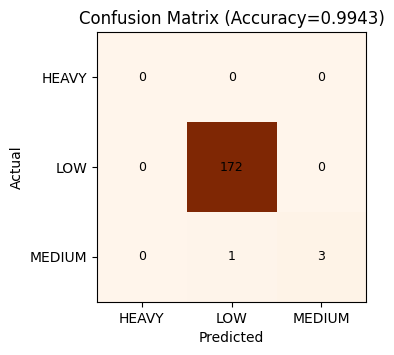

In [10]:
plt.figure(figsize=(4,3.5))
plt.imshow(cm, cmap='Oranges')
plt.xticks(range(3), le.classes_)
plt.yticks(range(3), le.classes_)
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=9)
plt.title(f'Confusion Matrix (Accuracy={acc:.4f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [11]:
#================================
#7. Real-time prediction function
#================================
#This function is used by the web API and dashboard.
def predict_traffic(g1, g2, g3, g4, g5, g6):
    row = np.array([[g1, g2, g3, g4, g5, g6]])
    pred = model.predict(row)[0]
    label = le.inverse_transform([pred])[0]
    total = int(row.sum())
    recommendation = 'GO' if label == 'LOW' else ('CAUTION' if label == 'MEDIUM' else 'NOT GO')
    return {'label': label, 'total_vehicles': total, 'recommendation': recommendation}

predict_traffic(1,0,1,0,0,0)


{'label': 'LOW', 'total_vehicles': 2, 'recommendation': 'GO'}

In [14]:
#=========================
#8. Dashboard integration
#=========================
#The app.py file exposes a FastAPI endpoint. The HTML dashboard can call it to update the recommendation status in real time.

from pathlib import Path
print(Path('app/app.py').read_text()[:1200])



from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
import pandas as pd
from fastapi.middleware.cors import CORSMiddleware

app = FastAPI(title="DL-TOLMON API")
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_credentials=True, allow_methods=["*"], allow_headers=["*"])

raw = pd.read_excel("../data_tol.xlsx", header=None)
raw.columns = [f"G{i}" for i in range(1,7)]
records = []
for col in raw.columns:
    for t in raw[col].dropna():
        records.append((pd.to_datetime(t), col, 1))
events = pd.DataFrame(records, columns=["timestamp","gate","vehicle"])
pivot = events.assign(v=1).pivot_table(index="timestamp", columns="gate", values="v", aggfunc="sum", fill_value=0).reset_index().sort_values("timestamp")
pivot["total_vehicles"] = pivot[[f"G{i}" for i in range(1,7)]].sum(axis=1)
def make_label(n):
   

In [15]:
#================
#9. Evaluation
#================
#Key findings
#Accuracy is high because the data is strongly dominated by LOW traffic.
#The rebuilt dataset contains 880 synchronized timestamps.
#Hidden pattern extraction shows the toll system is mostly in a low-congestion state, with very limited HEAVY observations.

#Limitation
#The dataset is highly imbalanced. Future work could include synthetic balancing, richer features, temporal windows, or reinforcement learning for gate-routing policy optimization.

from IPython.display import HTML, display
with open('dashboard_live.html', 'r') as f:
    html_content = f.read()
display(HTML(html_content))
